In [21]:
import numpy as np

#x=np.array([1.0,2.0, 4.0, 7.0])
#y=np.array([-1.0, 1.0, 2.0, 1.0])

x=np.array([0.0,0.2,0.4,0.8,1.2,1.6,2.0])
y=1+np.sin(3*x)

n=len(x)

#TABLA DE DIFERENCIAS DIVIDIDAS

D=np.zeros((n,n))                 #Tabla vacía
D[:,0]=y                           #Primera columna

for j in range(1,n):               #Orden de la diferencia
    for i in range(j,n):            #Recorre las filas

        D[i,j]=(D[i,j-1]-D[i-1,j-1]) / (x[i]-x[i-j])           #Formula recursiva

#TITULO DE LA TABLA

print("\nTABLA DE DIFERENCIAS DIVIDIDAS\n")
encabezado=["xi", "f(xi)", "D1", "D2", "D3", "D4", "D5", "D6"]
print("{:<6}".format(encabezado[0]), end="")                  #Imprime el xi

for h in encabezado[1:]:                                       #Recorre los títulos
    print("{:>10}".format(h), end="")                           #Alineación
print(h)

#IMPRESIÓN DE LA TABLA

for i in range(n):                            #Recorre filas
    print(f"{x[i]:<6.1f}", end="")             #Imprime xi

    for j in range(i+1):                        #parte triangular
        print(f"{D[i,j]:>10.2f}", end="")       #valor de la tabla
    print()
        
#COEFICIENTES DE NEWTON 

print("\nCOEFICIENTES DE NEWTON\n")
coef=[]                                     #Lista de coeficientes

for k in range(n):                          #Recorre la diagonal
    coef.append(D[k,k])                      #Guarda c_k
    print(f"c{k}={D[k,k]:.8f}")              #Imprime c_k

#POLINOMIO DE NEWTON
print("\nPOLINOMIO DE NEWTON\n")

P=f"{coef[0]:.5f}"                          #Primer término
#Terminos restantes

for k in range(1,n):
    termino=f"+ ({coef[k]:.5f})"           #Coeficientes

    for j in range(k):                       #factores
        termino+= f"(x-{x[j]:.1f})"          #Factor de Newton

    P+=termino                              #Agrega el término
print("P(x)=", P)                            #Imprime el polinomio
    
    





    



TABLA DE DIFERENCIAS DIVIDIDAS

xi         f(xi)        D1        D2        D3        D4        D5        D6D6
0.0         1.00
0.2         1.56      2.82
0.4         1.93      1.84     -2.47
0.8         1.68     -0.64     -4.13     -2.08
1.2         0.56     -2.79     -2.69      1.44      2.93
1.6         0.00     -1.38      1.76      3.71      1.62     -0.82
2.0         0.72      1.79      3.97      1.84     -1.17     -1.55     -0.37

COEFICIENTES DE NEWTON

c0=1.00000000
c1=2.82321237
c2=-2.46557326
c3=-2.08141431
c4=2.93351659
c5=-0.81823462
c6=-0.36747078

POLINOMIO DE NEWTON

P(x)= 1.00000+ (2.82321)(x-0.0)+ (-2.46557)(x-0.0)(x-0.2)+ (-2.08141)(x-0.0)(x-0.2)(x-0.4)+ (2.93352)(x-0.0)(x-0.2)(x-0.4)(x-0.8)+ (-0.81823)(x-0.0)(x-0.2)(x-0.4)(x-0.8)(x-1.2)+ (-0.36747)(x-0.0)(x-0.2)(x-0.4)(x-0.8)(x-1.2)(x-1.6)


ERRORES MAXIMOS
Equiespaciados h=1      : 1.9156331475012045
Chebyshev mismo numero : 0.10915351076845337
Equiespaciados h=0.25   : 104379.92792682609
Chebyshev mismo numero : 0.0002893518858952948


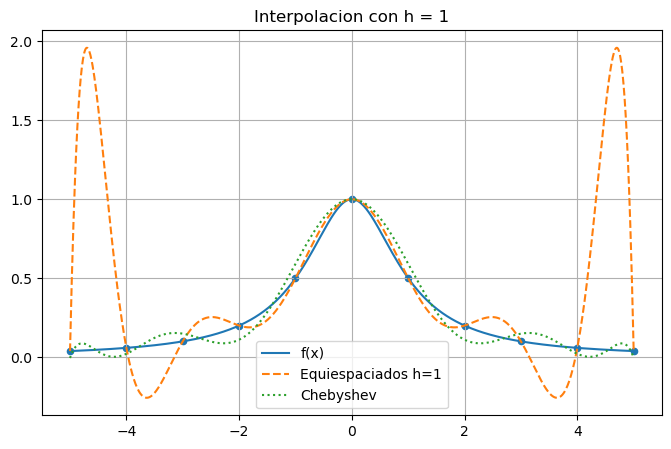

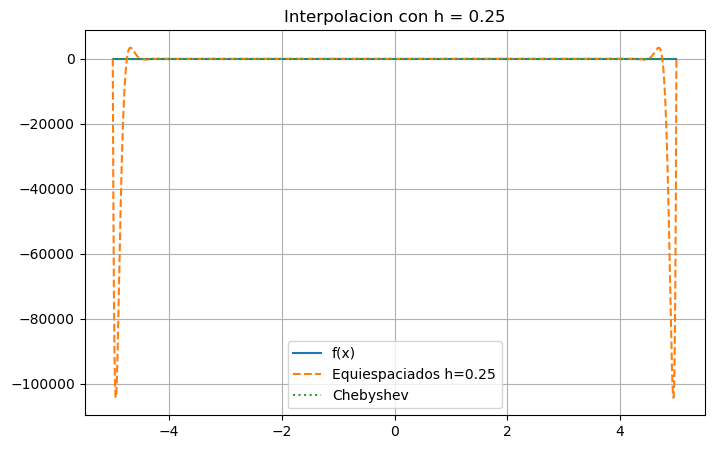

In [22]:
import numpy as np                                      # Libreria numerica
import matplotlib.pyplot as plt                         # Libreria para graficar

# -------------------------------------------------
# FUNCION DEL EJEMPLO 2.5
# -------------------------------------------------

def f(x):                                               # Define la funcion
    return 1/(x**2 + 1)                                 # f(x)=1/(x^2+1)

# -------------------------------------------------
# NODOS DE CHEBYSHEV EN [a,b]
# -------------------------------------------------

def nodos_chebyshev(a, b, n):                           # n es el grado
    i = np.arange(n+1)                                  # i = 0,1,...,n
    x = (b-a)/2*np.cos((2*i+1)*np.pi/(2*n+2)) + (b+a)/2 # Formula Chebyshev
    return np.sort(x)                                   # Ordena los nodos

# -------------------------------------------------
# TABLA DE DIFERENCIAS DIVIDIDAS
# -------------------------------------------------

def diferencias_divididas(x, y):                        # Recibe nodos y valores
    n = len(x)                                          # Numero de puntos
    D = np.zeros((n, n))                                # Tabla vacia
    D[:,0] = y                                          # Orden 0: f[xi]
    
    for j in range(1, n):                               # Recorre columnas
        for i in range(j, n):                           # Recorre filas
            D[i,j] = (D[i,j-1] - D[i-1,j-1]) / \
                     (x[i] - x[i-j])                    # Formula recursiva
    
    return D                                            # Devuelve la tabla

# -------------------------------------------------
# EVALUAR POLINOMIO DE NEWTON
# -------------------------------------------------

def eval_newton(xdato, D, x):                           # Evalua el polinomio
    n = len(xdato)                                      # Numero de nodos
    coef = [D[k,k] for k in range(n)]                   # Coeficientes ck
    
    p = coef[0]                                         # Primer termino
    prod = 1                                            # Producto inicial
    
    for k in range(1, n):                               # Terminos restantes
        prod = prod*(x - xdato[k-1])                    # Producto Newton
        p = p + coef[k]*prod                            # Suma termino
    
    return p                                            # Devuelve P(x)

# -------------------------------------------------
# DATOS DEL INTERVALO
# -------------------------------------------------

a = -5                                                  # Extremo izquierdo
b = 5                                                   # Extremo derecho

# -------------------------------------------------
# CASO 1: NODOS IGUALMENTE ESPACIADOS, h = 1
# -------------------------------------------------

x1 = np.arange(a, b+1, 1)                               # Nodos con paso h=1
y1 = f(x1)                                              # Valores f(xi)
D1 = diferencias_divididas(x1, y1)                      # Tabla dividida

#CASO 2: NODOS DE CHEVISHEV, Misma cantidad

n1=len(x1)-1    #grado del polinomio
xc1=nodos_chebyshev(a,b,n1)
yc1=f(xc1)
DC1=diferencias_divididas(xc1, yc1)  
# -------------------------------------------------
# CASO 3: NODOS IGUALMENTE ESPACIADOS, h = .25
# -------------------------------------------------

x2 = np.arange(a, b+0.25, 0.25)                               # Nodos con paso h=1
y2 = f(x2)                                              # Valores f(xi)
D2 = diferencias_divididas(x2, y2)                      # Tabla dividida

#CASO 4: NODOS DE CHEVISHEV, Misma cantidad

n2=len(x2)-1    #grado del polinomio
xc2=nodos_chebyshev(a,b,n2)
yc2=f(xc2)
DC2=diferencias_divididas(xc2, yc2)  

# -------------------------------------------------
# MALLA FINA PARA GRAFICAR
# -------------------------------------------------

xx = np.linspace(a, b, 1000)                            # Puntos para graficar
ff = f(xx)                                              # Funcion exacta

p1 = eval_newton(x1, D1, xx)                            # Polinomio h=1
pc1 = eval_newton(xc1, DC1, xx)                         # Polinomio Chebyshev h=1

p2 = eval_newton(x2, D2, xx)                            # Polinomio h=0.25
pc2 = eval_newton(xc2, DC2, xx)                         # Polinomio Chebyshev h=0.25

# -------------------------------------------------
# ERRORES MAXIMOS
# -------------------------------------------------

print("ERRORES MAXIMOS")                                # Titulo

print("Equiespaciados h=1      :", np.max(abs(ff-p1)))  # Error caso 1
print("Chebyshev mismo numero :", np.max(abs(ff-pc1)))  # Error caso 2
print("Equiespaciados h=0.25   :", np.max(abs(ff-p2)))  # Error caso 3
print("Chebyshev mismo numero :", np.max(abs(ff-pc2)))  # Error caso 4

# -------------------------------------------------
# GRAFICA PARA h = 1
# -------------------------------------------------

plt.figure(figsize=(8,5))                               # Tamano figura
plt.plot(xx, ff, label="f(x)")                          # Funcion exacta
plt.plot(xx, p1, "--", label="Equiespaciados h=1")      # Polinomio h=1
plt.plot(xx, pc1, ":", label="Chebyshev")               # Polinomio Chebyshev
plt.scatter(x1, y1, s=20)                               # Nodos equiespaciados
plt.title("Interpolacion con h = 1")                    # Titulo
plt.legend()                                            # Muestra leyenda
plt.grid()                                              # Activa grilla
plt.show()                                              # Muestra grafica

# -------------------------------------------------
# GRAFICA PARA h = 0.25
# -------------------------------------------------

plt.figure(figsize=(8,5))                               # Tamano figura
plt.plot(xx, ff, label="f(x)")                          # Funcion exacta
plt.plot(xx, p2, "--", label="Equiespaciados h=0.25")   # Polinomio h=0.25
plt.plot(xx, pc2, ":", label="Chebyshev")               # Polinomio Chebyshev
plt.title("Interpolacion con h = 0.25")                 # Titulo
plt.legend()                                            # Muestra leyenda
plt.grid()                                              # Activa grilla
plt.show()                                              # Muestra grafica